In [1]:
import sys

import matplotlib
import matplotlib.pyplot
import numpy
import pandas

sys.path.insert(0, "..")
from runner.utils import load_benchmark_metadata

# Load the results and metadata

In [2]:
# Load the metadata of the benchmarks.
all_metadata = load_benchmark_metadata("../results/metadata.yaml")

# Read the results of the pypsa-de-elec scaling benchmark.
pypsa_de_elec_results = pandas.read_csv("../results/pypsa_de_elec_scaling.csv")

# Change the solver name of "highs-ipm" to "highs-ipx".
pypsa_de_elec_results["Solver"] = pypsa_de_elec_results["Solver"].replace(
    {"highs-ipm": "highs-ipx"}
)

# Print the name of the benchmark instances.
pypsa_de_elec_results["bench-size"].sort_values().unique().tolist()

['pypsa-de-elec-10-1h',
 'pypsa-de-elec-12-1h',
 'pypsa-de-elec-14-1h',
 'pypsa-de-elec-16-1h',
 'pypsa-de-elec-18-1h',
 'pypsa-de-elec-2-1h',
 'pypsa-de-elec-20-1h',
 'pypsa-de-elec-22-1h',
 'pypsa-de-elec-24-1h',
 'pypsa-de-elec-26-1h',
 'pypsa-de-elec-28-1h',
 'pypsa-de-elec-30-1h',
 'pypsa-de-elec-32-1h',
 'pypsa-de-elec-34-1h',
 'pypsa-de-elec-36-1h',
 'pypsa-de-elec-38-1h',
 'pypsa-de-elec-4-1h',
 'pypsa-de-elec-40-1h',
 'pypsa-de-elec-42-1h',
 'pypsa-de-elec-44-1h',
 'pypsa-de-elec-46-1h',
 'pypsa-de-elec-48-1h',
 'pypsa-de-elec-50-1h',
 'pypsa-de-elec-52-1h',
 'pypsa-de-elec-54-1h',
 'pypsa-de-elec-56-1h',
 'pypsa-de-elec-58-1h',
 'pypsa-de-elec-6-1h',
 'pypsa-de-elec-60-1h',
 'pypsa-de-elec-8-1h']

In [3]:
# Define additional folders of pypsa-de-elec benchmark results to read.
pypsa_de_elec_additional_folders = [
    "../results/gcp-results/20260415-pypsa-de-elec-2-through-20-1h-mosek",
    "../results/gcp-results/20260422-pypsa-de-elec-2-through-20-1h-commercial",
]

# Read the results of the additional folders and concatenate them with the existing results.
pypsa_de_elec_additional_results = []
for i in range(0, 10):
    pypsa_de_elec_additional_results.append(
        pandas.read_csv(
            pypsa_de_elec_additional_folders[0]
            + f"/benchmark-instance-pypsa-de-elec-2-through-20-1h-mosek-{i:02d}-result.csv"
        )
    )
for i in range(0, 10):
    pypsa_de_elec_additional_results.append(
        pandas.read_csv(
            pypsa_de_elec_additional_folders[1]
            + f"/benchmark-instance-pypsa-de-elec-2-through-20-1h-commercial-{i:02d}-result.csv"
        )
    )
pypsa_de_elec_additional_results = pandas.concat(
    pypsa_de_elec_additional_results, ignore_index=True
)

# Remove the reference benchmark.
pypsa_de_elec_additional_results = pypsa_de_elec_additional_results[
    pypsa_de_elec_additional_results["Benchmark"] != "reference-benchmark"
].copy()

# Add a column for the bench-size ID.
pypsa_de_elec_additional_results["bench-size"] = (
    pypsa_de_elec_additional_results["Benchmark"]
    + "-"
    + pypsa_de_elec_additional_results["Size"]
)

# Add the additional results to the existing results.
pypsa_de_elec_results = pandas.concat(
    [pypsa_de_elec_results, pypsa_de_elec_additional_results], ignore_index=True
)

In [4]:
# Add selected metadata columns to the pypsa-de-elec results dataframe.
pypsa_de_elec_results["Variables"] = [
    all_metadata.loc[b, "Num. variables"] for b in pypsa_de_elec_results["bench-size"]
]
pypsa_de_elec_results["Constraints"] = [
    all_metadata.loc[b, "Num. constraints"] for b in pypsa_de_elec_results["bench-size"]
]
pypsa_de_elec_results["Problem class"] = [
    all_metadata.loc[b, "Problem class"] for b in pypsa_de_elec_results["bench-size"]
]
pypsa_de_elec_results["Temporal resolution"] = pypsa_de_elec_results["Size"].apply(
    lambda x: x.split("-")[1]
)
pypsa_de_elec_results["Spatial resolution"] = pypsa_de_elec_results["Size"].apply(
    lambda x: int(x.split("-")[0])
)

# Display the first few rows of the pypsa-de-elec results dataframe.
pypsa_de_elec_results.head()

,Benchmark,Size,Solver,Solver Version,Solver Release Year,Status,Termination Condition,Runtime (s),Memory Usage (MB),Objective Value,...,VM Instance Type,VM Zone,Solver benchmark version,bench-size,solver-version,Variables,Constraints,Problem class,Temporal resolution,Spatial resolution
0,pypsa-de-elec,10-1h,cbc,2.10.12,2024.0,TO,Timeout,86400.000000,1016.872,NaN,...,c4-standard-8,us-central1-a,7b54a96,pypsa-de-elec-10-1h,cbc-2.10.12,2111271,4502789,LP,1h,10
1,pypsa-de-elec,10-1h,cplex,22.1.2.0,2025.0,ok,optimal,199.485093,8839.036,5.604910e+09,...,c4-highmem-8,us-central1-a,65bc512,pypsa-de-elec-10-1h,NaN,2111271,4502789,LP,1h,10
2,pypsa-de-elec,10-1h,gurobi,13.0.0,2025.0,ok,optimal,123.321761,6719.304,5.604910e+09,...,c4-standard-8,us-central1-a,7b54a96,pypsa-de-elec-10-1h,gurobi-13.0.0,2111271,4502789,LP,1h,10
3,pypsa-de-elec,10-1h,highs,1.12.0,2025.0,ok,optimal,28396.892155,6195.704,5.604910e+09,...,c4-standard-8,us-central1-a,7b54a96,pypsa-de-elec-10-1h,highs-1.12.0,2111271,4502789,LP,1h,10
4,pypsa-de-elec,10-1h,highs-hipo,1.12.0-hipo,2025.0,ok,Optimal,2188.069117,4695.212,5.604910e+09,...,c4-standard-8,us-central1-a,7b54a96,pypsa-de-elec-10-1h,highs-hipo-1.12.0-hipo,2111271,4502789,LP,1h,10


In [5]:
# Define additional folders of pypsa-de-elec benchmark results to read.
pypsa_de_elec_uc_folders = [
    "../results/gcp-results/20260409-pypsa-de-elec-uc-2-nodes-scaling",
    "../results/gcp-results/20260415-pypsa-de-elec-uc-2-nodes-scaling-mosek",
    "../results/gcp-results/20260422-pypsa-de-elec-uc-2-nodes-scaling-comm",
    "../results/gcp-results/20260527-pypsa-de-elec-uc-2-nodes-scaling-cplex",
]

# Define the file paths for the results of the pypsa-de-elec-uc scaling benchmark.
pypsa_de_elec_uc_results = []
for i in range(0, 8):
    pypsa_de_elec_uc_results.append(
        pandas.read_csv(
            pypsa_de_elec_uc_folders[0]
            + f"/benchmark-instance-pypsa-de-elec-uc-2-nodes-scaling-{i:02d}-result.csv"
        )
    )
for i in range(1, 9):
    pypsa_de_elec_uc_results.append(
        pandas.read_csv(
            pypsa_de_elec_uc_folders[1]
            + f"/benchmark-instance-pypsa-de-elec-uc-2-nodes-scaling-mosek-{i:02d}-result.csv"
        )
    )
for i in range(1, 9):
    pypsa_de_elec_uc_results.append(
        pandas.read_csv(
            pypsa_de_elec_uc_folders[2]
            + f"/benchmark-instance-pypsa-de-elec-uc-2-nodes-scaling-comm-{i:02d}-result.csv"
        )
    )
pypsa_de_elec_uc_results = pandas.concat(pypsa_de_elec_uc_results, ignore_index=True)

# Remove the reference benchmark.
pypsa_de_elec_uc_results = pypsa_de_elec_uc_results[
    pypsa_de_elec_uc_results["Benchmark"] != "reference-benchmark"
].copy()

# Add a column for the bench-size ID.
pypsa_de_elec_uc_results["bench-size"] = (
    pypsa_de_elec_uc_results["Benchmark"] + "-" + pypsa_de_elec_uc_results["Size"]
)

# Print the name of the benchmark instances.
pypsa_de_elec_uc_results["bench-size"].sort_values().unique().tolist()

# Read the results of the pypsa-de-sec scaling benchmark.
pypsa_de_sec_results = pandas.read_csv("../results/pypsa_de_sec_scaling.csv")

# Change the solver name of "highs-ipm" to "highs-ipx".
pypsa_de_sec_results["Solver"] = pypsa_de_sec_results["Solver"].replace(
    {"highs-ipm": "highs-ipx"}
)

# Remove the reference benchmark.
pypsa_de_sec_results = pypsa_de_sec_results[
    pypsa_de_sec_results["Benchmark"] != "reference-benchmark"
].copy()

# Add a column for the bench-size ID.
pypsa_de_sec_results["bench-size"] = (
    pypsa_de_sec_results["Benchmark"] + "-" + pypsa_de_sec_results["Size"]
)

# Print the name of the benchmark instances.
pypsa_de_sec_results["bench-size"].sort_values().unique().tolist()

['pypsa-de-sec-10-1h',
 'pypsa-de-sec-12-1h',
 'pypsa-de-sec-14-1h',
 'pypsa-de-sec-16-1h',
 'pypsa-de-sec-18-1h',
 'pypsa-de-sec-2-1h',
 'pypsa-de-sec-20-1h',
 'pypsa-de-sec-4-1h',
 'pypsa-de-sec-6-1h',
 'pypsa-de-sec-8-1h']

In [6]:
# Load the metadata of the pypsa-de-elec-uc benchmarks.
pypsa_de_elec_uc_metadata = load_benchmark_metadata("metadata-pypsa-de-elec-uc.yaml")

# Load the metadata of the pypsa-de-sec benchmarks.
pypsa_de_sec_metadata = load_benchmark_metadata("metadata-pypsa-de-sec.yaml")

In [7]:
# Add selected metadata columns to the pypsa-de-elec-uc results dataframe.
pypsa_de_elec_uc_results["Variables"] = [
    pypsa_de_elec_uc_metadata.loc[b, "Num. variables"]
    for b in pypsa_de_elec_uc_results["bench-size"]
]
pypsa_de_elec_uc_results["Continuous variables"] = [
    pypsa_de_elec_uc_metadata.loc[b, "Num. continuous variables"]
    for b in pypsa_de_elec_uc_results["bench-size"]
]
pypsa_de_elec_uc_results["Integer variables"] = [
    pypsa_de_elec_uc_metadata.loc[b, "Num. integer variables"]
    for b in pypsa_de_elec_uc_results["bench-size"]
]
pypsa_de_elec_uc_results["Constraints"] = [
    pypsa_de_elec_uc_metadata.loc[b, "Num. constraints"]
    for b in pypsa_de_elec_uc_results["bench-size"]
]
pypsa_de_elec_uc_results["Problem class"] = [
    pypsa_de_elec_uc_metadata.loc[b, "Problem class"]
    for b in pypsa_de_elec_uc_results["bench-size"]
]
pypsa_de_elec_uc_results["Temporal resolution"] = pypsa_de_elec_uc_results[
    "Size"
].apply(lambda x: int(x.split("-")[1].strip("h")))
pypsa_de_elec_uc_results["Spatial resolution"] = pypsa_de_elec_uc_results["Size"].apply(
    lambda x: int(x.split("-")[0])
)

# Display the first few rows of the pypsa-de-elec-uc results dataframe.
pypsa_de_elec_uc_results.head()

# Add selected metadata columns to the pypsa-de-sec results dataframe.
pypsa_de_sec_results["Variables"] = [
    pypsa_de_sec_metadata.loc[b, "Num. variables"]
    for b in pypsa_de_sec_results["bench-size"]
]

pypsa_de_sec_results["Constraints"] = [
    pypsa_de_sec_metadata.loc[b, "Num. constraints"]
    for b in pypsa_de_sec_results["bench-size"]
]

pypsa_de_sec_results["Problem class"] = [
    pypsa_de_sec_metadata.loc[b, "Problem class"]
    for b in pypsa_de_sec_results["bench-size"]
]

pypsa_de_sec_results["Temporal resolution"] = pypsa_de_sec_results["Size"].apply(
    lambda x: int(x.split("-")[1].strip("h"))
)

pypsa_de_sec_results["Spatial resolution"] = pypsa_de_sec_results["Size"].apply(
    lambda x: int(x.split("-")[0])
)

pypsa_de_sec_results.head()

,Benchmark,Size,Solver,Solver Version,Solver Release Year,Status,Termination Condition,Runtime (s),Memory Usage (MB),Objective Value,...,VM Instance Type,VM Zone,Solver benchmark version,source_file,bench-size,Variables,Constraints,Problem class,Temporal resolution,Spatial resolution
0,pypsa-de-sec,10-1h,cplex,22.1.2.0,2025.0,OOM,Out of Memory,NaN,NaN,NaN,...,c4-highmem-8,us-central1-a,acb819f,NaN,pypsa-de-sec-10-1h,10994701,23328888,LP,1,10
1,pypsa-de-sec,10-1h,gurobi,12.0.3,2025.0,ok,optimal,3034.276458,17471.360,8.097905e+10,...,c4-highmem-8,us-central1-a,5bdf255,benchmark-instance-pypsa-de-sec-2-nodes-scalin...,pypsa-de-sec-10-1h,10994701,23328888,LP,1,10
2,pypsa-de-sec,10-1h,knitro,15.1.0,2025.0,ER,Error,86400.000000,202.132,NaN,...,c4-highmem-8,us-central1-a,5bdf255,benchmark-instance-pypsa-de-sec-2-nodes-scalin...,pypsa-de-sec-10-1h,10994701,23328888,LP,1,10
3,pypsa-de-sec,10-1h,mosek,11.1.10,2025.0,ok,optimal,2068.240136,42764.540,8.097905e+10,...,c4-highmem-8,us-central1-a,5bdf255,benchmark-instance-pypsa-de-sec-2-nodes-scalin...,pypsa-de-sec-10-1h,10994701,23328888,LP,1,10
4,pypsa-de-sec,12-1h,cplex,22.1.2.0,2025.0,TO,Timeout,86400.000000,54983.240,NaN,...,c4-highmem-8,us-central1-a,acb819f,NaN,pypsa-de-sec-12-1h,13359680,28234681,LP,1,12


# Define color, marker, and name mappings for solvers

In [8]:
# Define the color map for the solvers.
color_map = {
    "cbc": "#F9CD5A",  # yellow
    "gurobi": "#F66C49",  # red
    "highs": "#43BF94",  # green
    "scip": "#3B82F6",  # blue
    "mosek": "#782211",  # brown
    "cplex": "#88E3F2",  # cyan
    "xpress": "#7C3AED",  # purple
    "knitro": "#FF00FF",  # magenta
}

# Define the marker map for the solvers.
marker_map = {
    "cbc": "o",  # yellow
    "gurobi": "d",  # red
    "highs": "^",  # green
    "scip": "X",  # blue
    "mosek": "s",  # brown
    "cplex": "P",  # cyan
    "xpress": "v",  # purple
    "knitro": "*",  # magenta
}

# Define the name map for the solvers.
name_map = {
    "cbc": "CBC",
    "glpk": "GLPK",
    "gurobi": "Gurobi",
    "highs": "HiGHS",
    "scip": "SCIP",
    "mosek": "MOSEK",
    "cplex": "CPLEX",
    "xpress": "XPRESS",
    "knitro": "Knitro",
}

# Analyze the PyPSA-DE scaling benchmarks

In [9]:
# Make sure that all problems are the correct problem class.
assert (pypsa_de_elec_results["Problem class"] == "LP").all()
assert (pypsa_de_elec_uc_results["Problem class"] == "MILP").all()
assert (pypsa_de_sec_results["Problem class"] == "LP").all()

# Initialize a list to store the latest version for each solver.
latest_versions_pypsa_de_elec_results = []

for solver in color_map.keys():
    # Filter results for the current solver.
    solver_results = pypsa_de_elec_results[
        pypsa_de_elec_results["Solver"] == solver
    ].copy()

    # Keep only the latest version of the solver.
    solver_results = solver_results[
        solver_results["Solver Release Year"]
        == solver_results["Solver Release Year"].max()
    ]

    # Append the results of the latest version to the list.
    latest_versions_pypsa_de_elec_results.append(solver_results)

# Concatenate the results of the latest versions of all solvers into a single DataFrame.
pypsa_de_elec_results = pandas.concat(
    latest_versions_pypsa_de_elec_results, ignore_index=True
)

# Sort the results by spatial resolution.
pypsa_de_elec_results = pypsa_de_elec_results.sort_values(by="Spatial resolution")

# Initialize a list to store the latest version for each solver.
latest_versions_pypsa_de_elec_uc_results = []

for solver in color_map.keys():
    # Filter results for the current solver.
    solver_results = pypsa_de_elec_uc_results[
        pypsa_de_elec_uc_results["Solver"] == solver
    ].copy()

    # Keep only the latest version of the solver.
    solver_results = solver_results[
        solver_results["Solver Release Year"]
        == solver_results["Solver Release Year"].max()
    ]

    # Append the results of the latest version to the list.
    latest_versions_pypsa_de_elec_uc_results.append(solver_results)

# Concatenate the results of the latest versions of all solvers into a single DataFrame.
pypsa_de_elec_uc_results = pandas.concat(
    latest_versions_pypsa_de_elec_uc_results, ignore_index=True
)

# Sort the results by spatial resolution.
pypsa_de_elec_uc_results = pypsa_de_elec_uc_results.sort_values(
    by="Temporal resolution"
)

# Initialize a list to store the latest version for each solver.
latest_versions_pypsa_de_sec_results = []

for solver in color_map.keys():
    solver_results = pypsa_de_sec_results[
        pypsa_de_sec_results["Solver"] == solver
    ].copy()

    solver_results = solver_results[
        solver_results["Solver Release Year"]
        == solver_results["Solver Release Year"].max()
    ]

    latest_versions_pypsa_de_sec_results.append(solver_results)

pypsa_de_sec_results = pandas.concat(
    latest_versions_pypsa_de_sec_results,
    ignore_index=True,
)

pypsa_de_sec_results = pypsa_de_sec_results.sort_values(by="Temporal resolution")

# Plot the runtime of the PyPSA-DE problems by solver as a function of the spatial and temporal resolution.

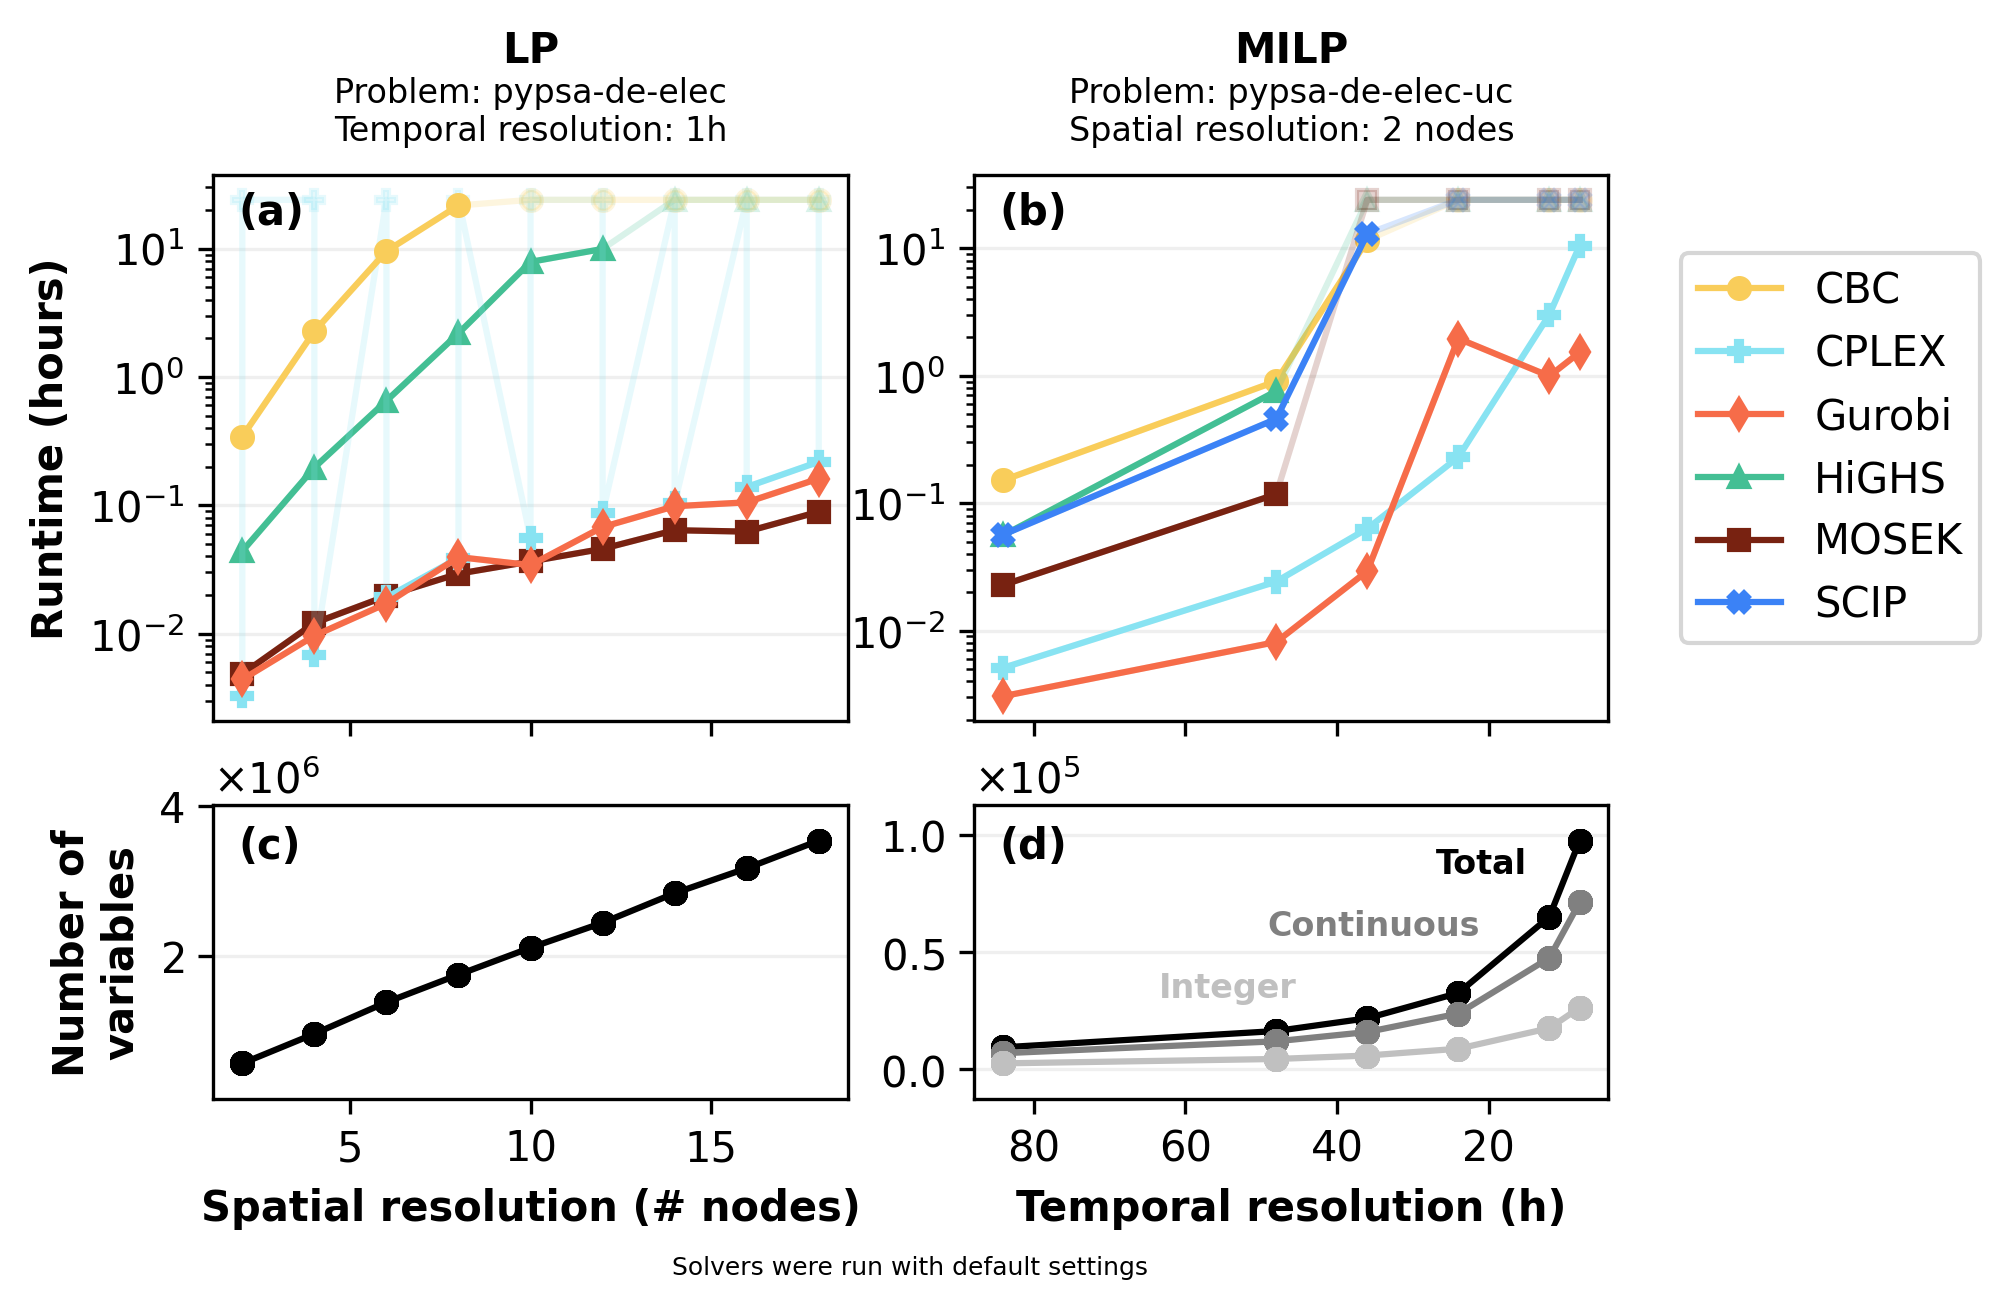

In [10]:
# Define the timeout threshold in hours.
timeout_threshold = 24

# Initialize the figure and axis.
fig, axs = matplotlib.pyplot.subplots(
    2,
    2,
    figsize=(6, 4),
    dpi=300,
    sharex="col",
    gridspec_kw={"height_ratios": [0.65, 0.35]},
)

x_axis_limits_lp = (2, 18)
x_axis_limits_milp = (8, 84)

excluded_solvers = ["knitro", "xpress"]

# LP runtime
for solver in pypsa_de_elec_results["Solver"].unique():
    if solver.lower() in excluded_solvers:
        continue

    solver_results = pypsa_de_elec_results[
        pypsa_de_elec_results["Solver"] == solver
    ].copy()

    solver_results["Runtime (s)"] = solver_results["Runtime (s)"] / 3600

    solver_results = solver_results[
        (solver_results["Spatial resolution"] >= x_axis_limits_lp[0])
        & (solver_results["Spatial resolution"] <= x_axis_limits_lp[1])
    ]

    is_not_solved = (
        solver_results["Status"].isin(["TO", "OOM", "ER"])
        | (
            (solver_results["Status"] == "warning")
            & (solver_results["Objective Value"].isna())
        )
        | (solver_results["Objective Value"] == 0)
    )

    solver_results.loc[is_not_solved, "Runtime (s)"] = timeout_threshold

    axs[0, 0].plot(
        solver_results["Spatial resolution"],
        solver_results["Runtime (s)"],
        marker=marker_map.get(solver, None),
        markersize=5,
        color=color_map.get(solver, None),
        alpha=0.2,
    )

    solver_results.loc[is_not_solved, "Runtime (s)"] = numpy.nan

    axs[0, 0].plot(
        solver_results["Spatial resolution"],
        solver_results["Runtime (s)"],
        marker=marker_map.get(solver, None),
        markersize=5,
        label=name_map.get(solver, solver),
        color=color_map.get(solver, None),
    )

axs[0, 0].set_ylabel("Runtime (hours)", weight="bold")
axs[0, 0].set_yscale("log")
axs[0, 0].grid(axis="y", alpha=0.2)
axs[0, 0].text(
    0.04, 0.91, "(a)", transform=axs[0, 0].transAxes, fontsize=10, weight="bold"
)

# MILP runtime
solvers = pypsa_de_elec_uc_results["Solver"].unique().tolist()
solvers.sort()

for solver in solvers:
    if solver.lower() in excluded_solvers:
        continue

    solver_results = pypsa_de_elec_uc_results[
        pypsa_de_elec_uc_results["Solver"] == solver
    ].copy()

    solver_results["Runtime (s)"] = solver_results["Runtime (s)"] / 3600

    solver_results = solver_results[
        (solver_results["Temporal resolution"] >= x_axis_limits_milp[0])
        & (solver_results["Temporal resolution"] <= x_axis_limits_milp[1])
    ]

    is_not_solved = (
        solver_results["Status"].isin(["TO", "OOM", "ER"])
        | (
            (solver_results["Status"] == "warning")
            & (solver_results["Objective Value"].isna())
        )
        | (solver_results["Objective Value"] == 0)
    )

    solver_results.loc[is_not_solved, "Runtime (s)"] = timeout_threshold

    axs[0, 1].plot(
        solver_results["Temporal resolution"],
        solver_results["Runtime (s)"],
        marker=marker_map.get(solver, None),
        markersize=5,
        color=color_map.get(solver, None),
        alpha=0.2,
    )

    solver_results.loc[is_not_solved, "Runtime (s)"] = numpy.nan

    axs[0, 1].plot(
        solver_results["Temporal resolution"],
        solver_results["Runtime (s)"],
        marker=marker_map.get(solver, None),
        markersize=5,
        label=name_map.get(solver, solver),
        color=color_map.get(solver, None),
    )

axs[0, 1].set_yscale("log")
axs[0, 1].grid(axis="y", alpha=0.2)
axs[0, 1].xaxis.set_inverted(True)
axs[0, 1].text(
    0.04, 0.91, "(b)", transform=axs[0, 1].transAxes, fontsize=10, weight="bold"
)
axs[0, 1].legend(loc="center", bbox_to_anchor=(1.35, 0.5))

# Bottom-left: LP variables
resolutions_to_plot = pypsa_de_elec_results[
    pypsa_de_elec_results["Spatial resolution"].isin(
        range(x_axis_limits_lp[0], x_axis_limits_lp[1] + 1)
    )
]
axs[1, 0].plot(
    resolutions_to_plot["Spatial resolution"],
    resolutions_to_plot["Variables"],
    marker="o",
    markersize=5,
    color="black",
)

y_lims = axs[1, 0].get_ylim()
axs[1, 0].set_ylim(
    bottom=y_lims[0] - 0.1 * (y_lims[1] - y_lims[0]),
    top=y_lims[1] + 0.1 * (y_lims[1] - y_lims[0]),
)
axs[1, 0].ticklabel_format(axis="y", style="sci", scilimits=(0, 0))
axs[1, 0].yaxis.get_major_formatter().set_useMathText(True)
axs[1, 0].set_ylabel("Number of\nvariables", weight="bold")
axs[1, 0].set_xlabel("Spatial resolution (# nodes)", weight="bold")
axs[1, 0].grid(axis="y", alpha=0.2)
axs[1, 0].text(
    0.04, 0.82, "(c)", transform=axs[1, 0].transAxes, fontsize=10, weight="bold"
)

# Bottom-right: MILP variables
resolutions_to_plot = pypsa_de_elec_uc_results[
    pypsa_de_elec_uc_results["Temporal resolution"].isin(
        range(x_axis_limits_milp[0], x_axis_limits_milp[1] + 1)
    )
]
axs[1, 1].plot(
    resolutions_to_plot["Temporal resolution"],
    resolutions_to_plot["Variables"],
    marker="o",
    markersize=5,
    color="black",
)
axs[1, 1].plot(
    resolutions_to_plot["Temporal resolution"],
    resolutions_to_plot["Continuous variables"],
    marker="o",
    markersize=5,
    color="grey",
)
axs[1, 1].plot(
    resolutions_to_plot["Temporal resolution"],
    resolutions_to_plot["Integer variables"],
    marker="o",
    markersize=5,
    color="silver",
)

y_lims = axs[1, 1].get_ylim()
axs[1, 1].set_ylim(
    bottom=y_lims[0] - 0.1 * (y_lims[1] - y_lims[0]),
    top=y_lims[1] + 0.1 * (y_lims[1] - y_lims[0]),
)
axs[1, 1].ticklabel_format(axis="y", style="sci", scilimits=(0, 0))
axs[1, 1].yaxis.get_major_formatter().set_useMathText(True)
axs[1, 1].set_xlabel("Temporal resolution (h)", weight="bold")
axs[1, 1].grid(axis="y", alpha=0.2)

axs[1, 1].text(
    0.8,
    0.8,
    "Total",
    transform=axs[1, 1].transAxes,
    ha="center",
    va="center",
    color="black",
    weight="bold",
    fontsize=8,
)
axs[1, 1].text(
    0.63,
    0.59,
    "Continuous",
    transform=axs[1, 1].transAxes,
    ha="center",
    va="center",
    color="grey",
    weight="bold",
    fontsize=8,
)
axs[1, 1].text(
    0.4,
    0.38,
    "Integer",
    transform=axs[1, 1].transAxes,
    ha="center",
    va="center",
    color="silver",
    weight="bold",
    fontsize=8,
)

axs[1, 1].text(
    0.04, 0.82, "(d)", transform=axs[1, 1].transAxes, fontsize=10, weight="bold"
)

# Titles
axs[0, 0].text(
    0.5,
    1.19,
    "LP",
    ha="center",
    va="bottom",
    transform=axs[0, 0].transAxes,
    fontsize=10,
    weight="bold",
)
axs[0, 0].text(
    0.5,
    1.05,
    "Problem: pypsa-de-elec\nTemporal resolution: 1h",
    ha="center",
    va="bottom",
    transform=axs[0, 0].transAxes,
    fontsize=8,
)

axs[0, 1].text(
    0.5,
    1.19,
    "MILP",
    ha="center",
    va="bottom",
    transform=axs[0, 1].transAxes,
    fontsize=10,
    weight="bold",
)
axs[0, 1].text(
    0.5,
    1.05,
    "Problem: pypsa-de-elec-uc\nSpatial resolution: 2 nodes",
    ha="center",
    va="bottom",
    transform=axs[0, 1].transAxes,
    fontsize=8,
)

fig.text(
    0.38,
    -0.03,
    "Solvers were run with default settings",
    ha="left",
    va="center",
    fontsize=6,
    clip_on=False,
)

fig.savefig(
    "figures/state_of_all_solvers__scaling_analysis.png",
    bbox_inches="tight",
    dpi=300,
)

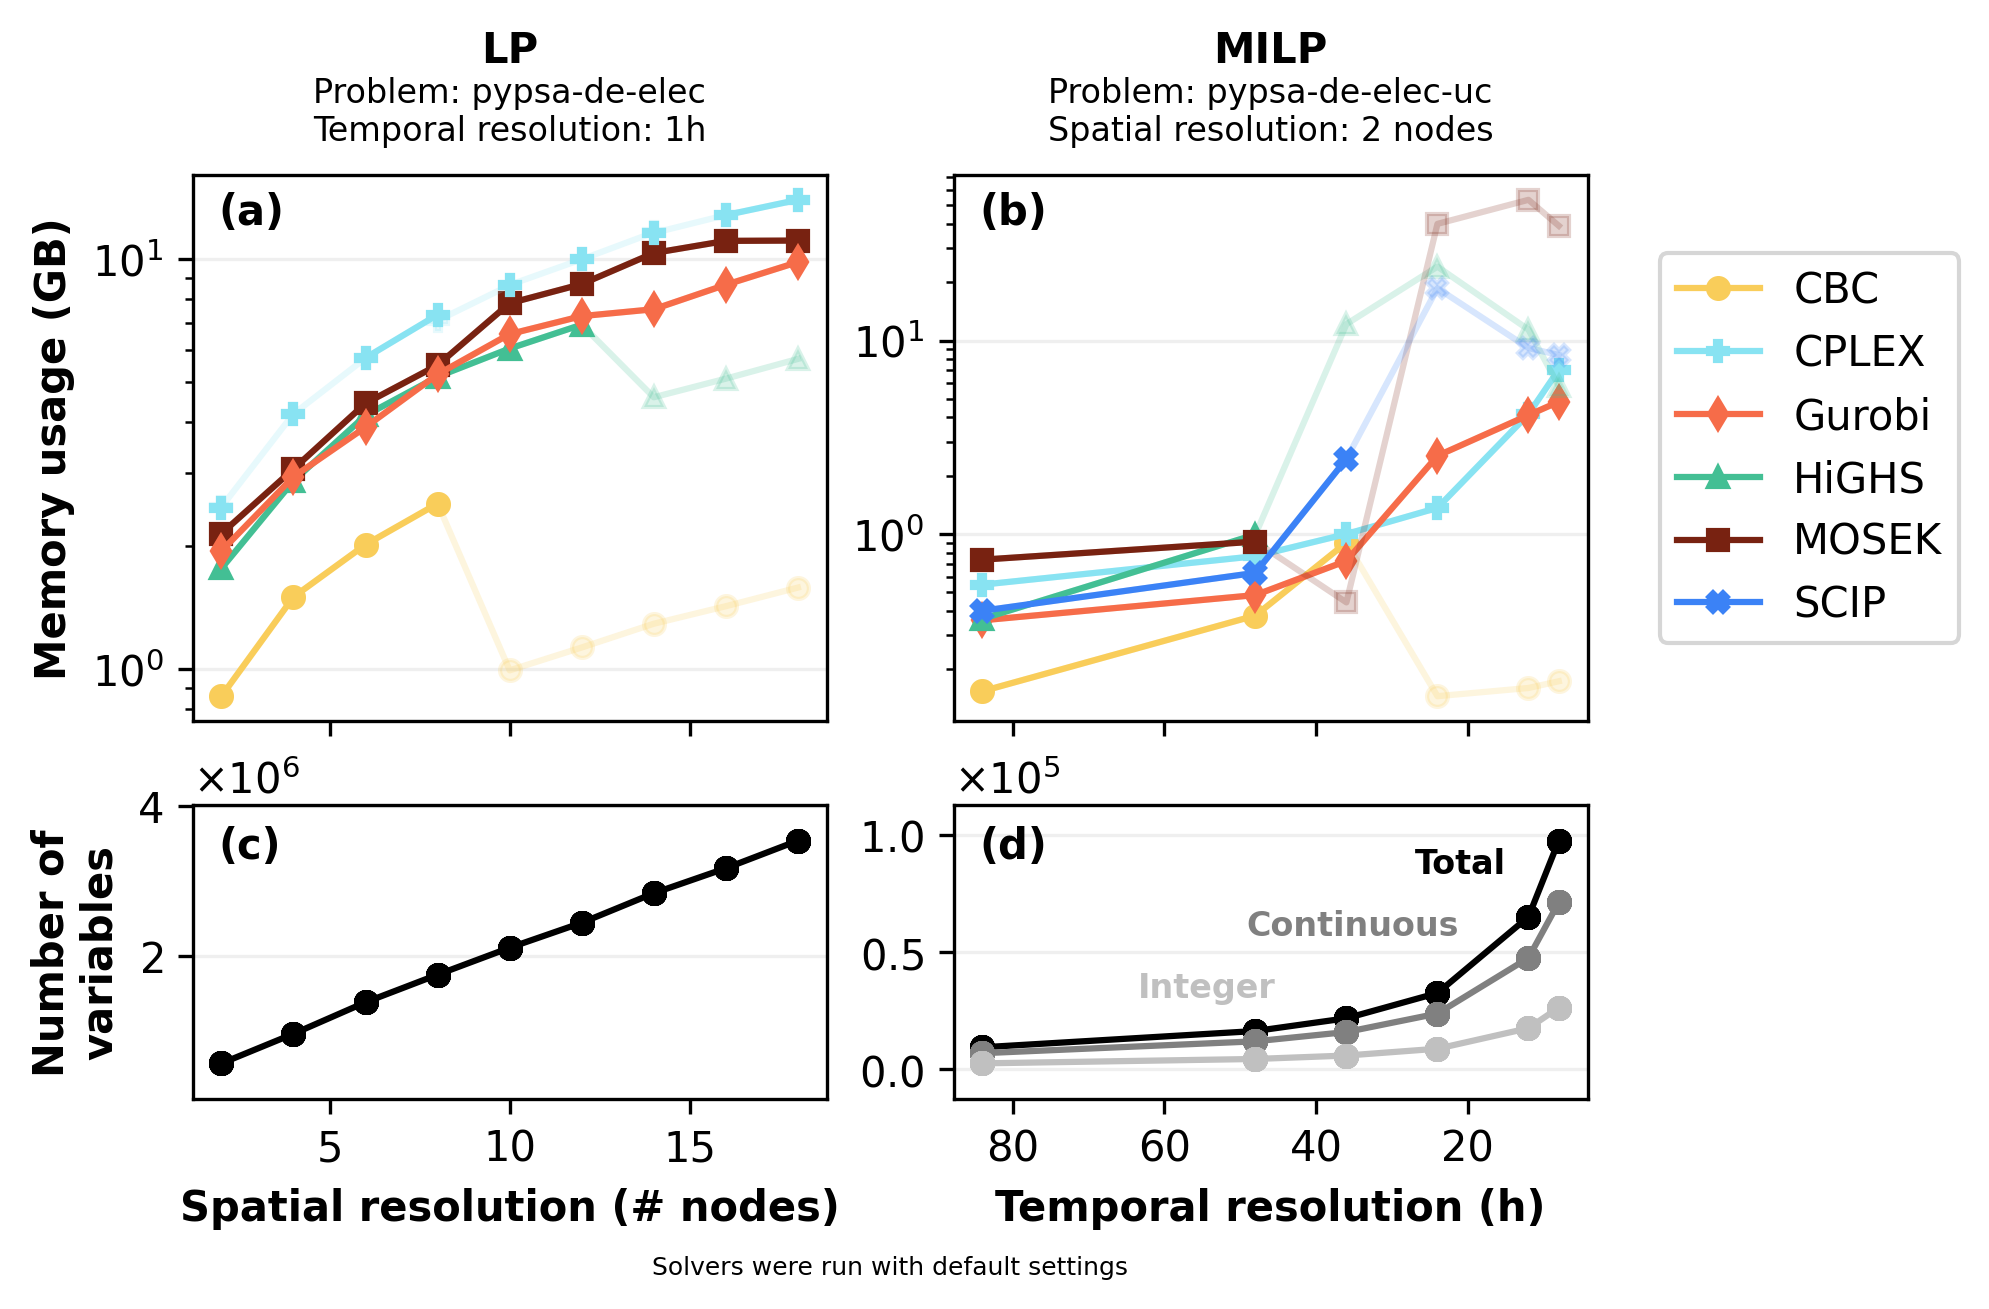

In [11]:
# Initialize the figure and axis.
fig, axs = matplotlib.pyplot.subplots(
    2,
    2,
    figsize=(6, 4),
    dpi=300,
    sharex="col",
    gridspec_kw={"height_ratios": [0.65, 0.35]},
)

x_axis_limits_lp = (2, 18)
x_axis_limits_milp = (8, 84)

memory_col = "Memory Usage (MB)"

# LP memory usage
for solver in pypsa_de_elec_results["Solver"].unique():
    # Skip KNITRO and XPRESS
    if solver.lower() in ["knitro", "xpress"]:
        continue

    solver_results = pypsa_de_elec_results[
        pypsa_de_elec_results["Solver"] == solver
    ].copy()

    # Convert MB to GB.
    solver_results["Memory Usage (GB)"] = solver_results[memory_col] / 1024

    solver_results = solver_results[
        (solver_results["Spatial resolution"] >= x_axis_limits_lp[0])
        & (solver_results["Spatial resolution"] <= x_axis_limits_lp[1])
    ]

    is_not_solved = (
        solver_results["Status"].isin(["TO", "OOM", "ER"])
        | (
            (solver_results["Status"] == "warning")
            & (solver_results["Objective Value"].isna())
        )
        | (solver_results["Objective Value"] == 0)
    )

    # Faint line: include all available memory values.
    axs[0, 0].plot(
        solver_results["Spatial resolution"],
        solver_results["Memory Usage (GB)"],
        marker=marker_map.get(solver, None),
        markersize=5,
        color=color_map.get(solver, None),
        alpha=0.2,
    )

    # Main line: show only successful runs.
    solver_results.loc[is_not_solved, "Memory Usage (GB)"] = numpy.nan

    axs[0, 0].plot(
        solver_results["Spatial resolution"],
        solver_results["Memory Usage (GB)"],
        marker=marker_map.get(solver, None),
        markersize=5,
        label=name_map.get(solver, solver),
        color=color_map.get(solver, None),
    )

axs[0, 0].set_ylabel(
    "Memory usage (GB)",
    weight="bold",
)
axs[0, 0].set_yscale("log")
axs[0, 0].grid(axis="y", alpha=0.2)
axs[0, 0].text(
    0.04,
    0.91,
    "(a)",
    transform=axs[0, 0].transAxes,
    fontsize=10,
    weight="bold",
)

# MILP memory usage
solvers = pypsa_de_elec_uc_results["Solver"].unique().tolist()
solvers.sort()

for solver in solvers:
    # Skip KNITRO and XPRESS
    if solver.lower() in ["knitro", "xpress"]:
        continue

    solver_results = pypsa_de_elec_uc_results[
        pypsa_de_elec_uc_results["Solver"] == solver
    ].copy()

    # Convert MB to GB.
    solver_results["Memory Usage (GB)"] = solver_results[memory_col] / 1024

    solver_results = solver_results[
        (solver_results["Temporal resolution"] >= x_axis_limits_milp[0])
        & (solver_results["Temporal resolution"] <= x_axis_limits_milp[1])
    ]

    is_not_solved = (
        solver_results["Status"].isin(["TO", "OOM", "ER"])
        | (
            (solver_results["Status"] == "warning")
            & (solver_results["Objective Value"].isna())
        )
        | (solver_results["Objective Value"] == 0)
    )

    # Faint line: include all available memory values.
    axs[0, 1].plot(
        solver_results["Temporal resolution"],
        solver_results["Memory Usage (GB)"],
        marker=marker_map.get(solver, None),
        markersize=5,
        color=color_map.get(solver, None),
        alpha=0.2,
    )

    # Main line: show only successful runs.
    solver_results.loc[is_not_solved, "Memory Usage (GB)"] = numpy.nan

    axs[0, 1].plot(
        solver_results["Temporal resolution"],
        solver_results["Memory Usage (GB)"],
        marker=marker_map.get(solver, None),
        markersize=5,
        label=name_map.get(solver, solver),
        color=color_map.get(solver, None),
    )

axs[0, 1].set_yscale("log")
axs[0, 1].grid(axis="y", alpha=0.2)
axs[0, 1].xaxis.set_inverted(True)
axs[0, 1].text(
    0.04,
    0.91,
    "(b)",
    transform=axs[0, 1].transAxes,
    fontsize=10,
    weight="bold",
)

axs[0, 1].legend(
    loc="center",
    bbox_to_anchor=(1.35, 0.5),
)

# Bottom-left: LP variables
resolutions_to_plot = pypsa_de_elec_results[
    pypsa_de_elec_results["Spatial resolution"].isin(
        range(
            x_axis_limits_lp[0],
            x_axis_limits_lp[1] + 1,
        )
    )
]

axs[1, 0].plot(
    resolutions_to_plot["Spatial resolution"],
    resolutions_to_plot["Variables"],
    marker="o",
    markersize=5,
    color="black",
)

y_lims = axs[1, 0].get_ylim()

axs[1, 0].set_ylim(
    bottom=y_lims[0] - 0.1 * (y_lims[1] - y_lims[0]),
    top=y_lims[1] + 0.1 * (y_lims[1] - y_lims[0]),
)

axs[1, 0].ticklabel_format(
    axis="y",
    style="sci",
    scilimits=(0, 0),
)

axs[1, 0].yaxis.get_major_formatter().set_useMathText(True)

axs[1, 0].set_ylabel(
    "Number of\nvariables",
    weight="bold",
)

axs[1, 0].set_xlabel(
    "Spatial resolution (# nodes)",
    weight="bold",
)

axs[1, 0].grid(axis="y", alpha=0.2)

axs[1, 0].text(
    0.04,
    0.82,
    "(c)",
    transform=axs[1, 0].transAxes,
    fontsize=10,
    weight="bold",
)

# Bottom-right: MILP variables
resolutions_to_plot = pypsa_de_elec_uc_results[
    pypsa_de_elec_uc_results["Temporal resolution"].isin(
        range(
            x_axis_limits_milp[0],
            x_axis_limits_milp[1] + 1,
        )
    )
]

axs[1, 1].plot(
    resolutions_to_plot["Temporal resolution"],
    resolutions_to_plot["Variables"],
    marker="o",
    markersize=5,
    color="black",
)

axs[1, 1].plot(
    resolutions_to_plot["Temporal resolution"],
    resolutions_to_plot["Continuous variables"],
    marker="o",
    markersize=5,
    color="grey",
)

axs[1, 1].plot(
    resolutions_to_plot["Temporal resolution"],
    resolutions_to_plot["Integer variables"],
    marker="o",
    markersize=5,
    color="silver",
)

y_lims = axs[1, 1].get_ylim()

axs[1, 1].set_ylim(
    bottom=y_lims[0] - 0.1 * (y_lims[1] - y_lims[0]),
    top=y_lims[1] + 0.1 * (y_lims[1] - y_lims[0]),
)

axs[1, 1].ticklabel_format(
    axis="y",
    style="sci",
    scilimits=(0, 0),
)

axs[1, 1].yaxis.get_major_formatter().set_useMathText(True)

axs[1, 1].set_xlabel(
    "Temporal resolution (h)",
    weight="bold",
)

axs[1, 1].grid(axis="y", alpha=0.2)

axs[1, 1].text(
    0.8,
    0.8,
    "Total",
    transform=axs[1, 1].transAxes,
    ha="center",
    va="center",
    color="black",
    weight="bold",
    fontsize=8,
)

axs[1, 1].text(
    0.63,
    0.59,
    "Continuous",
    transform=axs[1, 1].transAxes,
    ha="center",
    va="center",
    color="grey",
    weight="bold",
    fontsize=8,
)

axs[1, 1].text(
    0.4,
    0.38,
    "Integer",
    transform=axs[1, 1].transAxes,
    ha="center",
    va="center",
    color="silver",
    weight="bold",
    fontsize=8,
)

axs[1, 1].text(
    0.04,
    0.82,
    "(d)",
    transform=axs[1, 1].transAxes,
    fontsize=10,
    weight="bold",
)

# Titles
axs[0, 0].text(
    0.5,
    1.19,
    "LP",
    ha="center",
    va="bottom",
    transform=axs[0, 0].transAxes,
    fontsize=10,
    weight="bold",
)

axs[0, 0].text(
    0.5,
    1.05,
    "Problem: pypsa-de-elec\nTemporal resolution: 1h",
    ha="center",
    va="bottom",
    transform=axs[0, 0].transAxes,
    fontsize=8,
)

axs[0, 1].text(
    0.5,
    1.19,
    "MILP",
    ha="center",
    va="bottom",
    transform=axs[0, 1].transAxes,
    fontsize=10,
    weight="bold",
)

axs[0, 1].text(
    0.5,
    1.05,
    "Problem: pypsa-de-elec-uc\nSpatial resolution: 2 nodes",
    ha="center",
    va="bottom",
    transform=axs[0, 1].transAxes,
    fontsize=8,
)

fig.text(
    0.38,
    -0.03,
    "Solvers were run with default settings",
    ha="left",
    va="center",
    fontsize=6,
    clip_on=False,
)

fig.savefig(
    "figures/state_of_all_solvers__memory_scaling_analysis.png",
    bbox_inches="tight",
    dpi=300,
)

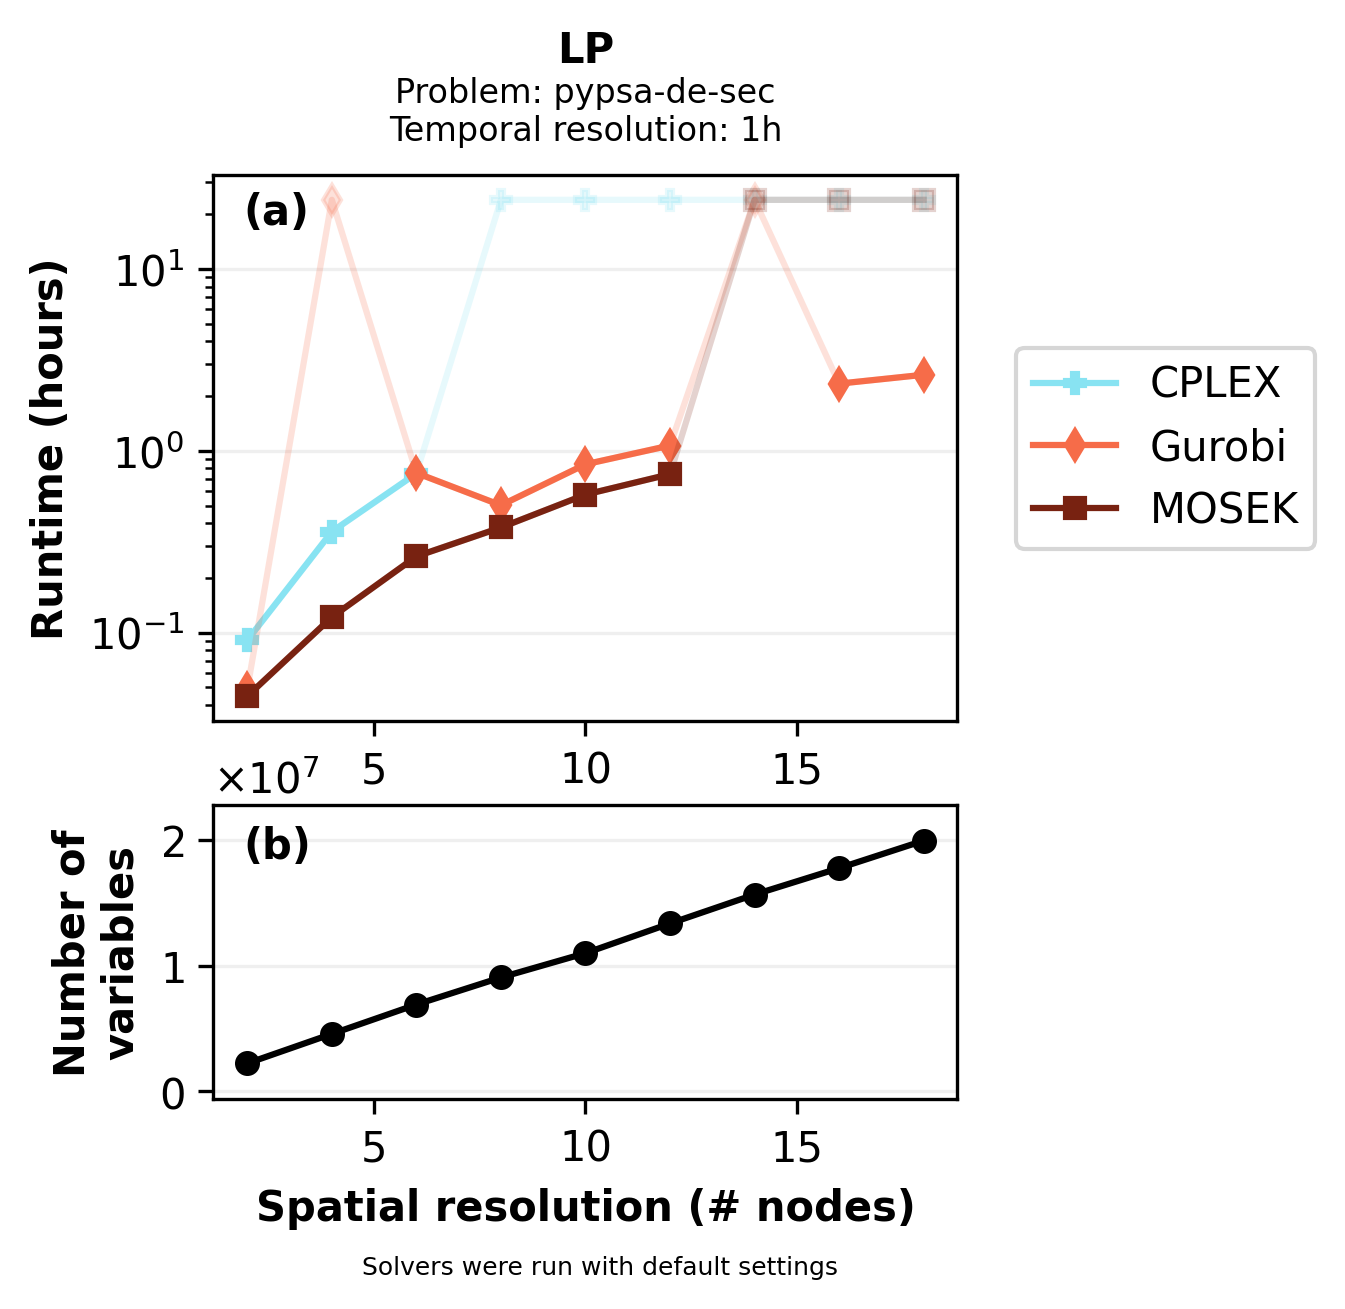

In [12]:
# Define the timeout threshold in hours.
timeout_threshold = 24

# Initialize the figure and axis.
fig, axs = matplotlib.pyplot.subplots(
    2,
    1,
    figsize=(3.2, 4),
    dpi=300,
    sharex=False,
    gridspec_kw={"height_ratios": [0.65, 0.35]},
)

x_axis_limits_lp = (2, 18)

excluded_solvers = ["knitro", "xpress"]

# Top: LP runtime
for solver in sorted(pypsa_de_sec_results["Solver"].unique()):
    if solver.lower() in excluded_solvers:
        continue

    solver_results = pypsa_de_sec_results[
        pypsa_de_sec_results["Solver"] == solver
    ].copy()

    solver_results["Runtime (hours)"] = solver_results["Runtime (s)"] / 3600

    solver_results = solver_results[
        solver_results["Spatial resolution"].between(
            x_axis_limits_lp[0],
            x_axis_limits_lp[1],
        )
    ].copy()

    solver_results = solver_results.sort_values("Spatial resolution")

    is_not_solved = (
        solver_results["Status"].isin(["TO", "OOM", "ER"])
        | (
            (solver_results["Status"] == "warning")
            & (solver_results["Objective Value"].isna())
        )
        | (solver_results["Objective Value"] == 0)
    )

    # Transparent line including timeout/non-solved runs
    solver_results.loc[is_not_solved, "Runtime (hours)"] = timeout_threshold

    axs[0].plot(
        solver_results["Spatial resolution"],
        solver_results["Runtime (hours)"],
        marker=marker_map.get(solver, None),
        markersize=5,
        color=color_map.get(solver, None),
        alpha=0.2,
    )

    # Main line excluding timeout/non-solved runs
    solver_results.loc[is_not_solved, "Runtime (hours)"] = numpy.nan

    axs[0].plot(
        solver_results["Spatial resolution"],
        solver_results["Runtime (hours)"],
        marker=marker_map.get(solver, None),
        markersize=5,
        label=name_map.get(solver, solver),
        color=color_map.get(solver, None),
    )

axs[0].set_ylabel("Runtime (hours)", weight="bold")
axs[0].set_yscale("log")
axs[0].grid(axis="y", alpha=0.2)

axs[0].text(
    0.04,
    0.91,
    "(a)",
    transform=axs[0].transAxes,
    fontsize=10,
    weight="bold",
)

axs[0].text(
    0.5,
    1.19,
    "LP",
    ha="center",
    va="bottom",
    transform=axs[0].transAxes,
    fontsize=10,
    weight="bold",
)

axs[0].text(
    0.5,
    1.05,
    "Problem: pypsa-de-sec\nTemporal resolution: 1h",
    ha="center",
    va="bottom",
    transform=axs[0].transAxes,
    fontsize=8,
)

axs[0].legend(
    loc="center",
    bbox_to_anchor=(1.28, 0.5),
)

# Bottom: LP variables
resolutions_to_plot = (
    pypsa_de_sec_results[
        pypsa_de_sec_results["Spatial resolution"].between(
            x_axis_limits_lp[0],
            x_axis_limits_lp[1],
        )
    ][["Spatial resolution", "Variables"]]
    .drop_duplicates()
    .sort_values("Spatial resolution")
)

axs[1].plot(
    resolutions_to_plot["Spatial resolution"],
    resolutions_to_plot["Variables"],
    marker="o",
    markersize=5,
    color="black",
)

y_lims = axs[1].get_ylim()

axs[1].set_ylim(
    bottom=y_lims[0] - 0.1 * (y_lims[1] - y_lims[0]),
    top=y_lims[1] + 0.1 * (y_lims[1] - y_lims[0]),
)

axs[1].ticklabel_format(
    axis="y",
    style="sci",
    scilimits=(0, 0),
)

axs[1].yaxis.get_major_formatter().set_useMathText(True)

axs[1].set_ylabel(
    "Number of\nvariables",
    weight="bold",
)

axs[1].set_xlabel(
    "Spatial resolution (# nodes)",
    weight="bold",
)

axs[1].grid(axis="y", alpha=0.2)

axs[1].text(
    0.04,
    0.82,
    "(b)",
    transform=axs[1].transAxes,
    fontsize=10,
    weight="bold",
)

fig.text(
    0.28,
    -0.03,
    "Solvers were run with default settings",
    ha="left",
    va="center",
    fontsize=6,
    clip_on=False,
)

fig.savefig(
    "figures/state_of_all_solvers__scaling_analysis_sec.png",
    bbox_inches="tight",
    dpi=300,
)

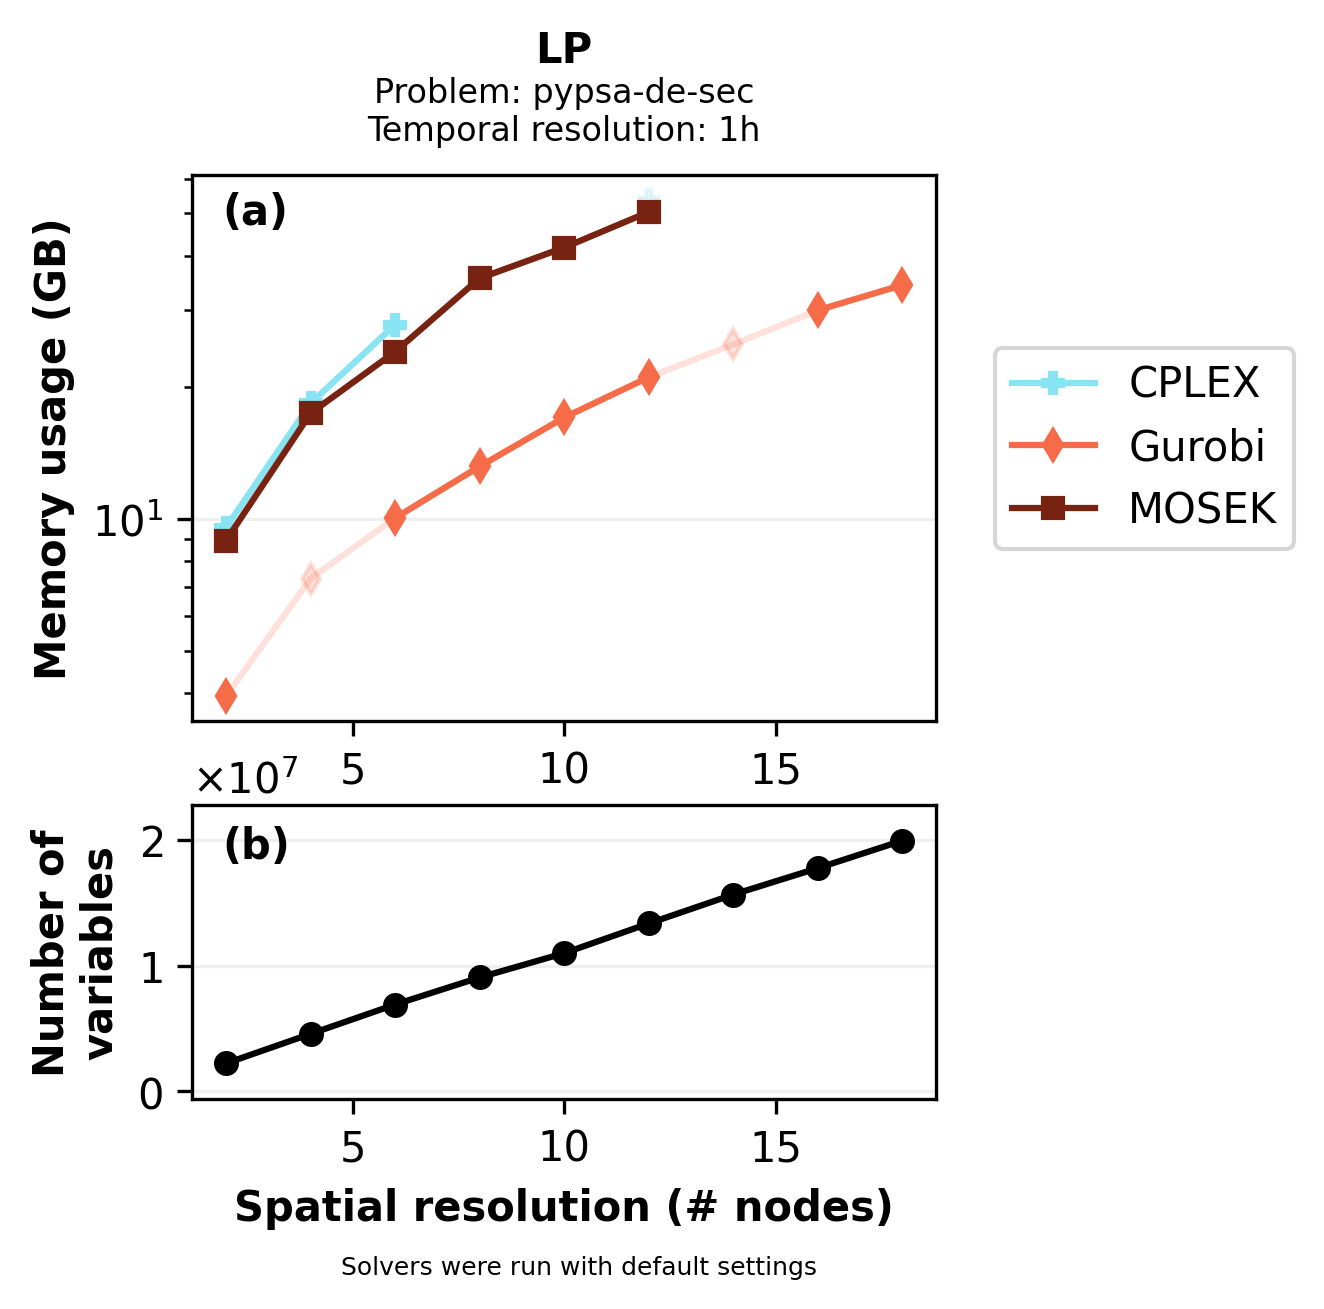

In [13]:
# Initialize the figure and axis.
fig, axs = matplotlib.pyplot.subplots(
    2,
    1,
    figsize=(3.2, 4),
    dpi=300,
    sharex=False,
    gridspec_kw={"height_ratios": [0.65, 0.35]},
)

x_axis_limits_lp = (2, 18)

memory_col = "Memory Usage (MB)"
excluded_solvers = ["knitro", "xpress"]

# Top: LP memory usage
for solver in sorted(pypsa_de_sec_results["Solver"].unique()):
    if solver.lower() in excluded_solvers:
        continue

    solver_results = pypsa_de_sec_results[
        pypsa_de_sec_results["Solver"] == solver
    ].copy()

    solver_results["Memory Usage (GB)"] = solver_results[memory_col] / 1024

    solver_results = solver_results[
        solver_results["Spatial resolution"].between(
            x_axis_limits_lp[0],
            x_axis_limits_lp[1],
        )
    ].copy()

    solver_results = solver_results.sort_values("Spatial resolution")

    is_not_solved = (
        solver_results["Status"].isin(["TO", "OOM", "ER"])
        | (
            (solver_results["Status"] == "warning")
            & (solver_results["Objective Value"].isna())
        )
        | (solver_results["Objective Value"] == 0)
    )

    # Faint line: include all available memory values.
    axs[0].plot(
        solver_results["Spatial resolution"],
        solver_results["Memory Usage (GB)"],
        marker=marker_map.get(solver, None),
        markersize=5,
        color=color_map.get(solver, None),
        alpha=0.2,
    )

    # Main line: show only successful runs.
    solver_results.loc[is_not_solved, "Memory Usage (GB)"] = numpy.nan

    axs[0].plot(
        solver_results["Spatial resolution"],
        solver_results["Memory Usage (GB)"],
        marker=marker_map.get(solver, None),
        markersize=5,
        label=name_map.get(solver, solver),
        color=color_map.get(solver, None),
    )

axs[0].set_ylabel("Memory usage (GB)", weight="bold")
axs[0].set_yscale("log")
axs[0].grid(axis="y", alpha=0.2)

axs[0].text(
    0.04,
    0.91,
    "(a)",
    transform=axs[0].transAxes,
    fontsize=10,
    weight="bold",
)

axs[0].text(
    0.5,
    1.19,
    "LP",
    ha="center",
    va="bottom",
    transform=axs[0].transAxes,
    fontsize=10,
    weight="bold",
)

axs[0].text(
    0.5,
    1.05,
    "Problem: pypsa-de-sec\nTemporal resolution: 1h",
    ha="center",
    va="bottom",
    transform=axs[0].transAxes,
    fontsize=8,
)

axs[0].legend(
    loc="center",
    bbox_to_anchor=(1.28, 0.5),
)

# Bottom: LP variables
resolutions_to_plot = (
    pypsa_de_sec_results[
        pypsa_de_sec_results["Spatial resolution"].between(
            x_axis_limits_lp[0],
            x_axis_limits_lp[1],
        )
    ][["Spatial resolution", "Variables"]]
    .drop_duplicates()
    .sort_values("Spatial resolution")
)

axs[1].plot(
    resolutions_to_plot["Spatial resolution"],
    resolutions_to_plot["Variables"],
    marker="o",
    markersize=5,
    color="black",
)

y_lims = axs[1].get_ylim()

axs[1].set_ylim(
    bottom=y_lims[0] - 0.1 * (y_lims[1] - y_lims[0]),
    top=y_lims[1] + 0.1 * (y_lims[1] - y_lims[0]),
)

axs[1].ticklabel_format(
    axis="y",
    style="sci",
    scilimits=(0, 0),
)

axs[1].yaxis.get_major_formatter().set_useMathText(True)

axs[1].set_ylabel(
    "Number of\nvariables",
    weight="bold",
)

axs[1].set_xlabel(
    "Spatial resolution (# nodes)",
    weight="bold",
)

axs[1].grid(axis="y", alpha=0.2)

axs[1].text(
    0.04,
    0.82,
    "(b)",
    transform=axs[1].transAxes,
    fontsize=10,
    weight="bold",
)

fig.text(
    0.28,
    -0.03,
    "Solvers were run with default settings",
    ha="left",
    va="center",
    fontsize=6,
    clip_on=False,
)

fig.savefig(
    "figures/state_of_all_solvers__memory_scaling_analysis_sec.png",
    bbox_inches="tight",
    dpi=300,
)